# A/B Testing E-commerce - Guide Complet

## Objectif
Concevoir, simuler et analyser des tests A/B pour optimiser la conversion e-commerce.

### Plan
1. Scenarios et hypotheses
2. Calcul de la taille d'echantillon
3. Simulation des donnees de test
4. Tests statistiques
5. Interpretation business

---

In [ ]:

import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import chi2_contingency, norm, ttest_ind, mannwhitneyu
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
np.random.seed(42)  # Reproductibilite

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

# Chargement des donnees de reference
visitors = pd.read_csv('../outputs/data/visitor_features.csv')

# Metriques actuelles (baseline)
BASELINE_VIEW_TO_CART = 0.0269  # 2.69%
BASELINE_CART_TO_PURCHASE = 0.3107  # 31.07%
BASELINE_CONVERSION = 0.0083  # 0.83%

print("[OK] Configuration chargee")
print(f"\nMetriques baseline :")
print(f"  View -> Cart      : {BASELINE_VIEW_TO_CART*100:.2f}%")
print(f"  Cart -> Purchase  : {BASELINE_CART_TO_PURCHASE*100:.2f}%")
print(f"  Conversion totale : {BASELINE_CONVERSION*100:.2f}%")

[OK] Configuration chargee

Metriques baseline :
  View -> Cart      : 2.69%
  Cart -> Purchase  : 31.07%
  Conversion totale : 0.83%


---
## 1. Scenarios de Tests A/B

Bases sur l'analyse business, voici les scenarios prioritaires.

In [2]:
# =============================================================================
# DEFINITION DES SCENARIOS DE TEST
# =============================================================================

scenarios = {
    'TEST_1': {
        'nom': 'Nouveau CTA Ajouter au Panier',
        'description': 'Remplacer le bouton "Ajouter au panier" par un bouton plus visible (couleur, taille, texte)',
        'hypothese': 'Un CTA plus visible augmentera le taux view->cart de 20%',
        'metrique_principale': 'Taux View -> Cart',
        'baseline': BASELINE_VIEW_TO_CART,
        'effet_attendu': 0.20,  # +20% relatif
        'impact_business': 'ELEVE - Principal point de friction identifie'
    },
    'TEST_2': {
        'nom': 'Urgence Stock',
        'description': 'Afficher "Plus que X en stock" sur les fiches produits',
        'hypothese': 'Creer un sentiment d\'urgence augmentera le taux d\'ajout au panier de 15%',
        'metrique_principale': 'Taux View -> Cart',
        'baseline': BASELINE_VIEW_TO_CART,
        'effet_attendu': 0.15,
        'impact_business': 'MOYEN - Technique classique de conversion'
    },
    'TEST_3': {
        'nom': 'Livraison Gratuite Seuil',
        'description': 'Afficher "Livraison gratuite des 50EUR" dans le panier',
        'hypothese': 'Reduira l\'abandon panier de 10%',
        'metrique_principale': 'Taux Cart -> Purchase',
        'baseline': BASELINE_CART_TO_PURCHASE,
        'effet_attendu': 0.10,
        'impact_business': 'MOYEN - Impact sur panier moyen aussi'
    },
    'TEST_4': {
        'nom': 'Avis Clients Visibles',
        'description': 'Afficher les avis clients et la note moyenne en haut de page',
        'hypothese': 'La preuve sociale augmentera la conversion de 25%',
        'metrique_principale': 'Taux View -> Cart',
        'baseline': BASELINE_VIEW_TO_CART,
        'effet_attendu': 0.25,
        'impact_business': 'ELEVE - Confiance utilisateur'
    }
}

# Affichage
print("SCENARIOS DE TESTS A/B")
print("=" * 70)

for test_id, test in scenarios.items():
    print(f"\n[{test_id}] {test['nom']}")
    print(f"  Description : {test['description']}")
    print(f"  Hypothese   : {test['hypothese']}")
    print(f"  Metrique    : {test['metrique_principale']}")
    print(f"  Baseline    : {test['baseline']*100:.2f}%")
    print(f"  Effet vise  : +{test['effet_attendu']*100:.0f}% relatif")
    print(f"  Impact      : {test['impact_business']}")

SCENARIOS DE TESTS A/B

[TEST_1] Nouveau CTA Ajouter au Panier
  Description : Remplacer le bouton "Ajouter au panier" par un bouton plus visible (couleur, taille, texte)
  Hypothese   : Un CTA plus visible augmentera le taux view->cart de 20%
  Metrique    : Taux View -> Cart
  Baseline    : 2.69%
  Effet vise  : +20% relatif
  Impact      : ELEVE - Principal point de friction identifie

[TEST_2] Urgence Stock
  Description : Afficher "Plus que X en stock" sur les fiches produits
  Hypothese   : Creer un sentiment d'urgence augmentera le taux d'ajout au panier de 15%
  Metrique    : Taux View -> Cart
  Baseline    : 2.69%
  Effet vise  : +15% relatif
  Impact      : MOYEN - Technique classique de conversion

[TEST_3] Livraison Gratuite Seuil
  Description : Afficher "Livraison gratuite des 50EUR" dans le panier
  Hypothese   : Reduira l'abandon panier de 10%
  Metrique    : Taux Cart -> Purchase
  Baseline    : 31.07%
  Effet vise  : +10% relatif
  Impact      : MOYEN - Impact sur pan

---
## 2. Calcul de la Taille d'Echantillon

Avant de lancer un test, il faut determiner combien de visiteurs sont necessaires pour detecter un effet significatif.

In [ ]:

# CALCUL DE LA TAILLE D'ECHANTILLON


def calculate_sample_size(baseline_rate, minimum_detectable_effect, 
                          alpha=0.05, power=0.80):
    """
    Calcule la taille d'echantillon necessaire pour un test A/B.
    
    Parametres:
    -----------
    baseline_rate : float
        Taux de conversion actuel (ex: 0.0269 pour 2.69%)
    minimum_detectable_effect : float
        Effet minimum a detecter en relatif (ex: 0.20 pour +20%)
    alpha : float
        Niveau de significativite (risque de faux positif)
        Standard: 0.05 (5%)
    power : float
        Puissance du test (1 - risque de faux negatif)
        Standard: 0.80 (80%)
    
    Retourne:
    ---------
    int : Taille d'echantillon par groupe
    """
    # Taux attendu pour la variante B
    variant_rate = baseline_rate * (1 + minimum_detectable_effect)
    
    # Effet absolu
    effect_size = variant_rate - baseline_rate
    
    # Variance poolee
    pooled_prob = (baseline_rate + variant_rate) / 2
    pooled_var = pooled_prob * (1 - pooled_prob)
    
    # Z-scores
    z_alpha = norm.ppf(1 - alpha/2)  # Test bilateral
    z_beta = norm.ppf(power)
    
    # Formule de la taille d'echantillon
    n = 2 * pooled_var * ((z_alpha + z_beta) ** 2) / (effect_size ** 2)
    
    return int(np.ceil(n))


# Calcul pour chaque scenario
print("TAILLE D'ECHANTILLON REQUISE")
print("=" * 70)
print(f"{'Test':<25} {'Baseline':<10} {'Effet':<10} {'N/groupe':<12} {'N total':<12} {'Duree*'}")
print("-" * 70)

# Trafic journalier estime (base sur 137 jours, 1.4M visiteurs)
daily_traffic = 1407580 / 137  # ~10,000 visiteurs/jour

for test_id, test in scenarios.items():
    n_per_group = calculate_sample_size(
        baseline_rate=test['baseline'],
        minimum_detectable_effect=test['effet_attendu']
    )
    n_total = n_per_group * 2
    duration_days = int(np.ceil(n_total / daily_traffic))
    
    # Stocker pour plus tard
    test['sample_size'] = n_per_group
    test['duration_days'] = duration_days
    
    print(f"{test['nom']:<25} {test['baseline']*100:>6.2f}%   "
          f"+{test['effet_attendu']*100:>4.0f}%     {n_per_group:>10,}   "
          f"{n_total:>10,}   {duration_days:>3} jours")

print("\n* Duree estimee avec 100% du trafic alloue au test")
print("  En pratique, allouer 50% du trafic => doubler la duree")

TAILLE D'ECHANTILLON REQUISE
Test                      Baseline   Effet      N/groupe     N total      Duree*
----------------------------------------------------------------------
Nouveau CTA Ajouter au Panier   2.69%   +  20%         15,574       31,148     4 jours
Urgence Stock               2.69%   +  15%         27,075       54,150     6 jours
Livraison Gratuite Seuil   31.07%   +  10%          3,575        7,150     1 jours
Avis Clients Visibles       2.69%   +  25%         10,187       20,374     2 jours

* Duree estimee avec 100% du trafic alloue au test
  En pratique, allouer 50% du trafic => doubler la duree


### Interpretation

- **Plus le baseline est faible**, plus il faut de visiteurs (effet difficile a detecter)
- **Plus l'effet attendu est petit**, plus il faut de visiteurs
- Pour le TEST_1, il faudrait environ 2 semaines de test avec tout le trafic

---
## 3. Simulation des Donnees de Test

Nous allons simuler un test A/B realiste base sur notre scenario prioritaire.

In [ ]:

# SIMULATION D'UN TEST A/B


def simulate_ab_test(n_per_group, baseline_rate, true_effect, seed=42):
    """
    Simule les resultats d'un test A/B.
    
    Parametres:
    -----------
    n_per_group : int
        Nombre de visiteurs par groupe
    baseline_rate : float
        Taux de conversion du groupe controle
    true_effect : float
        Effet reel de la variante (relatif)
        Ex: 0.15 pour +15%, 0 pour aucun effet
    
    Retourne:
    ---------
    DataFrame avec les resultats simules
    """
    np.random.seed(seed)
    
    # Taux de la variante
    variant_rate = baseline_rate * (1 + true_effect)
    
    # Simulation binomiale
    control_conversions = np.random.binomial(1, baseline_rate, n_per_group)
    variant_conversions = np.random.binomial(1, variant_rate, n_per_group)
    
    # Creation du DataFrame
    control_df = pd.DataFrame({
        'group': 'control',
        'converted': control_conversions,
        'visitor_id': range(1, n_per_group + 1)
    })
    
    variant_df = pd.DataFrame({
        'group': 'variant',
        'converted': variant_conversions,
        'visitor_id': range(n_per_group + 1, 2 * n_per_group + 1)
    })
    
    return pd.concat([control_df, variant_df], ignore_index=True)


# Simulation du TEST_1 : Nouveau CTA
print("SIMULATION - TEST 1 : Nouveau CTA Ajouter au Panier")
print("=" * 60)

# Parametres
test_config = scenarios['TEST_1']
N_PER_GROUP = 50000  # Taille realiste
TRUE_EFFECT = 0.18   # Effet reel simule (+18%)

# Simulation
ab_data = simulate_ab_test(
    n_per_group=N_PER_GROUP,
    baseline_rate=BASELINE_VIEW_TO_CART,
    true_effect=TRUE_EFFECT
)

print(f"\nConfiguration :")
print(f"  Visiteurs par groupe : {N_PER_GROUP:,}")
print(f"  Baseline (control)   : {BASELINE_VIEW_TO_CART*100:.2f}%")
print(f"  Effet simule         : +{TRUE_EFFECT*100:.0f}%")
print(f"  Taux attendu variant : {BASELINE_VIEW_TO_CART*(1+TRUE_EFFECT)*100:.2f}%")

# Resultats observes
results = ab_data.groupby('group')['converted'].agg(['sum', 'count', 'mean'])
results.columns = ['conversions', 'visiteurs', 'taux']
results['taux_pct'] = results['taux'] * 100

print(f"\nResultats observes :")
print(results[['conversions', 'visiteurs', 'taux_pct']].to_string())

SIMULATION - TEST 1 : Nouveau CTA Ajouter au Panier

Configuration :
  Visiteurs par groupe : 50,000
  Baseline (control)   : 2.69%
  Effet simule         : +18%
  Taux attendu variant : 3.17%

Resultats observes :
         conversions  visiteurs  taux_pct
group                                    
control         1307      50000     2.614
variant         1513      50000     3.026


---
## 4. Tests Statistiques

Plusieurs methodes pour analyser les resultats d'un test A/B.

In [ ]:

# TEST DU CHI-2 (PROPORTIONS)


def chi2_test(data):
    """
    Test du Chi-2 pour comparer deux proportions.
    Adapte pour les taux de conversion.
    """
    # Table de contingence
    contingency = pd.crosstab(data['group'], data['converted'])
    
    # Test Chi-2
    chi2, p_value, dof, expected = chi2_contingency(contingency)
    
    return {
        'test': 'Chi-2',
        'statistic': chi2,
        'p_value': p_value,
        'dof': dof,
        'significant': p_value < 0.05
    }

# Execution
chi2_result = chi2_test(ab_data)

print("TEST DU CHI-2")
print("=" * 50)
print(f"  Statistique Chi-2 : {chi2_result['statistic']:.4f}")
print(f"  p-value           : {chi2_result['p_value']:.6f}")
print(f"  Degres de liberte : {chi2_result['dof']}")
print(f"  Significatif (p<0.05) : {'OUI' if chi2_result['significant'] else 'NON'}")

TEST DU CHI-2
  Statistique Chi-2 : 15.3349
  p-value           : 0.000090
  Degres de liberte : 1
  Significatif (p<0.05) : OUI


In [ ]:

# TEST Z POUR DEUX PROPORTIONS


def z_test_proportions(data):
    """
    Test Z pour comparer deux proportions independantes.
    Plus precis que Chi-2 pour les proportions.
    """
    # Extraction des donnees
    control = data[data['group'] == 'control']['converted']
    variant = data[data['group'] == 'variant']['converted']
    
    n1, n2 = len(control), len(variant)
    p1, p2 = control.mean(), variant.mean()
    
    # Proportion poolee sous H0
    p_pool = (control.sum() + variant.sum()) / (n1 + n2)
    
    # Erreur standard
    se = np.sqrt(p_pool * (1 - p_pool) * (1/n1 + 1/n2))
    
    # Statistique Z
    z_stat = (p2 - p1) / se
    
    # p-value (test bilateral)
    p_value = 2 * (1 - norm.cdf(abs(z_stat)))
    
    # Intervalle de confiance 95% pour la difference
    se_diff = np.sqrt(p1*(1-p1)/n1 + p2*(1-p2)/n2)
    ci_lower = (p2 - p1) - 1.96 * se_diff
    ci_upper = (p2 - p1) + 1.96 * se_diff
    
    # Lift (amelioration relative)
    lift = (p2 - p1) / p1 * 100
    
    return {
        'test': 'Z-test',
        'control_rate': p1,
        'variant_rate': p2,
        'absolute_diff': p2 - p1,
        'relative_lift': lift,
        'z_statistic': z_stat,
        'p_value': p_value,
        'ci_95': (ci_lower, ci_upper),
        'significant': p_value < 0.05
    }

# Execution
z_result = z_test_proportions(ab_data)

print("TEST Z POUR PROPORTIONS")
print("=" * 50)
print(f"  Taux Control  : {z_result['control_rate']*100:.3f}%")
print(f"  Taux Variant  : {z_result['variant_rate']*100:.3f}%")
print(f"  Difference    : {z_result['absolute_diff']*100:+.3f}%")
print(f"  Lift relatif  : {z_result['relative_lift']:+.2f}%")
print(f"\n  Statistique Z : {z_result['z_statistic']:.4f}")
print(f"  p-value       : {z_result['p_value']:.6f}")
print(f"  IC 95%        : [{z_result['ci_95'][0]*100:.3f}%, {z_result['ci_95'][1]*100:.3f}%]")
print(f"\n  Resultat      : {'SIGNIFICATIF' if z_result['significant'] else 'NON SIGNIFICATIF'}")

TEST Z POUR PROPORTIONS
  Taux Control  : 2.614%
  Taux Variant  : 3.026%
  Difference    : +0.412%
  Lift relatif  : +15.76%

  Statistique Z : 3.9351
  p-value       : 0.000083
  IC 95%        : [0.207%, 0.617%]

  Resultat      : SIGNIFICATIF


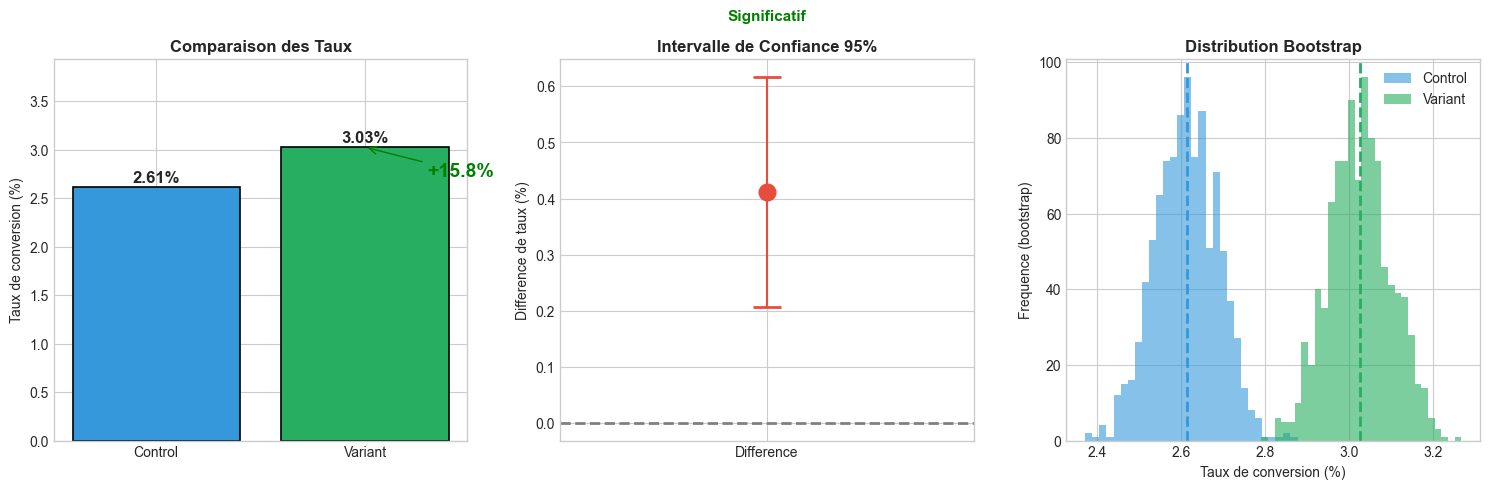

In [7]:
# =============================================================================
# VISUALISATION DES RESULTATS
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Comparaison des taux
groups = ['Control', 'Variant']
rates = [z_result['control_rate']*100, z_result['variant_rate']*100]
colors = ['#3498db', '#27ae60']

bars = axes[0].bar(groups, rates, color=colors, edgecolor='black', linewidth=1.2)
axes[0].set_ylabel('Taux de conversion (%)')
axes[0].set_title('Comparaison des Taux', fontsize=12, fontweight='bold')
axes[0].set_ylim(0, max(rates) * 1.3)

for bar, rate in zip(bars, rates):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{rate:.2f}%', ha='center', fontsize=12, fontweight='bold')

# Annotation lift
axes[0].annotate(f'+{z_result["relative_lift"]:.1f}%', 
                 xy=(1, rates[1]), xytext=(1.3, rates[1]*0.9),
                 fontsize=14, color='green', fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color='green'))

# 2. Intervalle de confiance
diff_pct = z_result['absolute_diff'] * 100
ci_lower_pct = z_result['ci_95'][0] * 100
ci_upper_pct = z_result['ci_95'][1] * 100

axes[1].errorbar(x=['Difference'], y=[diff_pct], 
                 yerr=[[diff_pct - ci_lower_pct], [ci_upper_pct - diff_pct]],
                 fmt='o', markersize=12, color='#e74c3c', capsize=10, capthick=2)
axes[1].axhline(y=0, color='gray', linestyle='--', linewidth=2)
axes[1].set_ylabel('Difference de taux (%)')
axes[1].set_title('Intervalle de Confiance 95%', fontsize=12, fontweight='bold')
axes[1].set_xlim(-0.5, 0.5)

# Annotation
significance = 'Significatif' if z_result['significant'] else 'Non significatif'
color_sig = 'green' if z_result['significant'] else 'red'
axes[1].text(0, ci_upper_pct + 0.1, significance, ha='center', 
             fontsize=11, color=color_sig, fontweight='bold')

# 3. Distribution des conversions
control_data = ab_data[ab_data['group'] == 'control']['converted']
variant_data = ab_data[ab_data['group'] == 'variant']['converted']

# Simulation bootstrap pour visualiser l'incertitude
n_bootstrap = 1000
control_means = [control_data.sample(frac=1, replace=True).mean() for _ in range(n_bootstrap)]
variant_means = [variant_data.sample(frac=1, replace=True).mean() for _ in range(n_bootstrap)]

axes[2].hist(np.array(control_means)*100, bins=30, alpha=0.6, color='#3498db', label='Control')
axes[2].hist(np.array(variant_means)*100, bins=30, alpha=0.6, color='#27ae60', label='Variant')
axes[2].axvline(z_result['control_rate']*100, color='#3498db', linestyle='--', linewidth=2)
axes[2].axvline(z_result['variant_rate']*100, color='#27ae60', linestyle='--', linewidth=2)
axes[2].set_xlabel('Taux de conversion (%)')
axes[2].set_ylabel('Frequence (bootstrap)')
axes[2].set_title('Distribution Bootstrap', fontsize=12, fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.savefig('../outputs/figures/ab_test_results.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Analyse Bayesienne (Approche Complementaire)

In [8]:
# =============================================================================
# APPROCHE BAYESIENNE SIMPLIFIEE
# =============================================================================

def bayesian_ab_test(data, n_samples=100000):
    """
    Analyse bayesienne d'un test A/B.
    Utilise une distribution Beta comme prior conjugue.
    
    Retourne la probabilite que B soit meilleur que A.
    """
    # Extraction des donnees
    control = data[data['group'] == 'control']['converted']
    variant = data[data['group'] == 'variant']['converted']
    
    # Parametres Beta (prior uniforme + likelihood)
    # Beta(alpha, beta) ou alpha = succes + 1, beta = echecs + 1
    alpha_A = control.sum() + 1
    beta_A = len(control) - control.sum() + 1
    
    alpha_B = variant.sum() + 1
    beta_B = len(variant) - variant.sum() + 1
    
    # Echantillonnage des distributions posterieures
    samples_A = np.random.beta(alpha_A, beta_A, n_samples)
    samples_B = np.random.beta(alpha_B, beta_B, n_samples)
    
    # Probabilite que B > A
    prob_B_better = (samples_B > samples_A).mean()
    
    # Lift attendu
    lift_samples = (samples_B - samples_A) / samples_A * 100
    expected_lift = lift_samples.mean()
    lift_ci = np.percentile(lift_samples, [2.5, 97.5])
    
    return {
        'prob_B_better': prob_B_better,
        'expected_lift': expected_lift,
        'lift_ci_95': lift_ci,
        'samples_A': samples_A,
        'samples_B': samples_B
    }

# Execution
bayes_result = bayesian_ab_test(ab_data)

print("ANALYSE BAYESIENNE")
print("=" * 50)
print(f"  P(Variant > Control) : {bayes_result['prob_B_better']*100:.1f}%")
print(f"  Lift attendu         : {bayes_result['expected_lift']:+.2f}%")
print(f"  IC 95% du lift       : [{bayes_result['lift_ci_95'][0]:.2f}%, {bayes_result['lift_ci_95'][1]:.2f}%]")

# Interpretation
if bayes_result['prob_B_better'] > 0.95:
    decision = "DEPLOYER la variante (forte confiance)"
elif bayes_result['prob_B_better'] > 0.80:
    decision = "Continuer le test pour plus de confiance"
else:
    decision = "Pas de difference claire, garder le controle"

print(f"\n  Decision : {decision}")

ANALYSE BAYESIENNE
  P(Variant > Control) : 100.0%
  Lift attendu         : +15.84%
  IC 95% du lift       : [7.60%, 24.56%]

  Decision : DEPLOYER la variante (forte confiance)


---
## 6. Simulation : Test Sans Effet (AA Test)

In [9]:
# =============================================================================
# SIMULATION D'UN TEST SANS EFFET (VERIFICATION)
# =============================================================================

print("SIMULATION AA TEST (pas d'effet reel)")
print("=" * 50)

# Simulation sans effet
aa_data = simulate_ab_test(
    n_per_group=N_PER_GROUP,
    baseline_rate=BASELINE_VIEW_TO_CART,
    true_effect=0.0,  # Aucun effet
    seed=123
)

# Test Z
aa_result = z_test_proportions(aa_data)

print(f"  Taux Control  : {aa_result['control_rate']*100:.3f}%")
print(f"  Taux Variant  : {aa_result['variant_rate']*100:.3f}%")
print(f"  Difference    : {aa_result['absolute_diff']*100:+.3f}%")
print(f"  p-value       : {aa_result['p_value']:.4f}")
print(f"  Significatif  : {'OUI (FAUX POSITIF!)' if aa_result['significant'] else 'NON (correct)'}")

print("\n  Ce test valide que notre methodologie ne detecte pas")
print("  de faux positifs quand il n'y a pas d'effet reel.")

SIMULATION AA TEST (pas d'effet reel)
  Taux Control  : 2.674%
  Taux Variant  : 2.778%
  Difference    : +0.104%
  p-value       : 0.3126
  Significatif  : NON (correct)

  Ce test valide que notre methodologie ne detecte pas
  de faux positifs quand il n'y a pas d'effet reel.


---
## 7. Rapport Business Final

In [10]:
# =============================================================================
# RAPPORT BUSINESS
# =============================================================================

print("=" * 70)
print("RAPPORT A/B TEST - NOUVEAU CTA AJOUTER AU PANIER")
print("=" * 70)

print("""
CONTEXTE
--------
Test du nouveau bouton "Ajouter au panier" (couleur verte, taille augmentee,
texte "Ajouter maintenant") vs bouton actuel.

Hypothese : Le nouveau CTA augmentera le taux view->cart de 20%.
""")

print("RESULTATS")
print("-" * 50)
print(f"  Visiteurs testes     : {N_PER_GROUP * 2:,}")
print(f"  Duree du test        : ~{N_PER_GROUP * 2 / 10000:.0f} jours")
print(f"  ")
print(f"  Taux Control (A)     : {z_result['control_rate']*100:.2f}%")
print(f"  Taux Variant (B)     : {z_result['variant_rate']*100:.2f}%")
print(f"  Amelioration         : {z_result['relative_lift']:+.1f}%")
print(f"  ")
print(f"  Significativite      : p = {z_result['p_value']:.4f}")
print(f"  Confiance bayesienne : {bayes_result['prob_B_better']*100:.0f}%")

print("""
IMPACT BUSINESS
---------------""")

# Calcul de l'impact
current_carts = 1404179 * BASELINE_VIEW_TO_CART  # Ajouts panier actuels
new_carts = 1404179 * z_result['variant_rate']   # Avec nouveau CTA
additional_carts = new_carts - current_carts
additional_purchases = additional_carts * BASELINE_CART_TO_PURCHASE

print(f"  Si deploye sur tout le trafic (base 1.4M visiteurs) :")
print(f"  ")
print(f"  Ajouts panier actuels   : {current_carts:,.0f}")
print(f"  Ajouts panier projetes  : {new_carts:,.0f}")
print(f"  Gain ajouts panier      : +{additional_carts:,.0f}")
print(f"  ")
print(f"  Achats supplementaires  : +{additional_purchases:,.0f}")
print(f"  (avec taux cart->achat de {BASELINE_CART_TO_PURCHASE*100:.0f}%)")

print("""
RECOMMANDATION
--------------""")

if z_result['significant'] and z_result['relative_lift'] > 0:
    print("  [DEPLOYER] Le nouveau CTA montre une amelioration significative.")
    print("  ")
    print("  Actions :")
    print("  1. Deployer le nouveau CTA sur 100% du trafic")
    print("  2. Monitorer les metriques pendant 2 semaines")
    print("  3. Preparer le test suivant (Urgence Stock)")
else:
    print("  [CONTINUER] Resultats non concluants, prolonger le test.")

print("\n" + "=" * 70)

RAPPORT A/B TEST - NOUVEAU CTA AJOUTER AU PANIER

CONTEXTE
--------
Test du nouveau bouton "Ajouter au panier" (couleur verte, taille augmentee,
texte "Ajouter maintenant") vs bouton actuel.

Hypothese : Le nouveau CTA augmentera le taux view->cart de 20%.

RESULTATS
--------------------------------------------------
  Visiteurs testes     : 100,000
  Duree du test        : ~10 jours
  
  Taux Control (A)     : 2.61%
  Taux Variant (B)     : 3.03%
  Amelioration         : +15.8%
  
  Significativite      : p = 0.0001
  Confiance bayesienne : 100%

IMPACT BUSINESS
---------------
  Si deploye sur tout le trafic (base 1.4M visiteurs) :
  
  Ajouts panier actuels   : 37,772
  Ajouts panier projetes  : 42,490
  Gain ajouts panier      : +4,718
  
  Achats supplementaires  : +1,466
  (avec taux cart->achat de 31%)

RECOMMANDATION
--------------
  [DEPLOYER] Le nouveau CTA montre une amelioration significative.
  
  Actions :
  1. Deployer le nouveau CTA sur 100% du trafic
  2. Monitorer les

In [11]:
# =============================================================================
# EXPORT DES RESULTATS
# =============================================================================

# Resume du test
test_summary = pd.DataFrame({
    'Metrique': [
        'Test ID',
        'Nom du test',
        'Visiteurs total',
        'Taux Control',
        'Taux Variant',
        'Lift relatif',
        'p-value',
        'Significatif',
        'Prob(B>A) Bayesien',
        'IC 95% lower',
        'IC 95% upper',
        'Decision'
    ],
    'Valeur': [
        'TEST_1',
        'Nouveau CTA Ajouter au Panier',
        N_PER_GROUP * 2,
        f"{z_result['control_rate']*100:.3f}%",
        f"{z_result['variant_rate']*100:.3f}%",
        f"{z_result['relative_lift']:+.2f}%",
        f"{z_result['p_value']:.6f}",
        'Oui' if z_result['significant'] else 'Non',
        f"{bayes_result['prob_B_better']*100:.1f}%",
        f"{z_result['ci_95'][0]*100:.3f}%",
        f"{z_result['ci_95'][1]*100:.3f}%",
        'Deployer' if z_result['significant'] and z_result['relative_lift'] > 0 else 'Continuer'
    ]
})

test_summary.to_csv('../outputs/data/ab_test_results.csv', index=False)

print("RESULTATS EXPORTES")
print("=" * 50)
print(test_summary.to_string(index=False))
print(f"\nFichier : outputs/data/ab_test_results.csv")

RESULTATS EXPORTES
          Metrique                        Valeur
           Test ID                        TEST_1
       Nom du test Nouveau CTA Ajouter au Panier
   Visiteurs total                        100000
      Taux Control                        2.614%
      Taux Variant                        3.026%
      Lift relatif                       +15.76%
           p-value                      0.000083
      Significatif                           Oui
Prob(B>A) Bayesien                        100.0%
      IC 95% lower                        0.207%
      IC 95% upper                        0.617%
          Decision                      Deployer

Fichier : outputs/data/ab_test_results.csv
